In [1]:
from glob import glob
import pandas as pd
import numpy as np
import subprocess
import shlex
from collections import defaultdict
from tqdm.auto import tqdm
from io import StringIO
from pqdm.processes import pqdm
from scipy.stats import fisher_exact
import os
import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
sns.set(font_scale=1.1, style="ticks", font="Helvetica")


In [14]:
HIT_THR = 0.0005
N_JOBS = 100


WORK_DIR = Path('/home/vladimirnoz/Projects/Codebook_Perspectives/Chromatin')

PEAKS_DIR = '/home/vladimirnoz/Projects/Codebook_Perspectives/peaks/chipseq+ghtselex'
TOPS_DIR = '/home/vladimirnoz/Projects/Codebook_Perspectives/TOPs/TOPs'
AS_TABLES_DIR = str(WORK_DIR / 'as_tables')
PEAKS_FILE = 'peaks.tsv'
TOPS_FILE = 'tops.tsv'
TOPS_AND_PEAKS_FILE = 'tops_and_peaks.tsv'

WORK_DIR = Path('/home/vladimirnoz/Projects/Codebook_Perspectives/Chromatin')
ATAC_FILE = WORK_DIR / 'agg_atac' / 'pvalues_agg_greater.tsv'
DNASE_FILE = WORK_DIR / 'agg_dnase' / 'pvalues_agg_greater.tsv'

FONTS_DIR = Path('/home/vladimirnoz/Projects/Codebook_Perspectives/fonts')

if FONTS_DIR.exists():
    font_files = font_manager.findSystemFonts(fontpaths=str(FONTS_DIR))
    for font_file in font_files:
        font_manager.fontManager.addfont(font_file)

os.chdir(WORK_DIR)

In [15]:
def distinct_snps(snps):
    header = ['#chr', 'start', 'end', 'id', 'motif_conc']
    groups = snps.groupby(header[:4]).apply(lambda row: row['motif_conc'].iloc[0], include_groups=False)
    snps = pd.DataFrame(groups, columns=['motif_conc']).reset_index()
    return snps.drop_duplicates().sort_values(by=['#chr', 'start', 'end'], ignore_index=True)

In [16]:
def solve_ambiguity(row):
    motif_conc = row['motif_conc']
    if motif_conc.nunique() == 1:
        return motif_conc.iloc[0]
    pvalues = row[['ref_comb_pval', 'alt_comb_pval']].min(axis=1)
    counts = motif_conc.value_counts()
    return motif_conc.iloc[pvalues.argmin()]
    if counts.iloc[0] != counts.iloc[1]:
        return counts.index[counts.argmax()]
    return motif_conc.iloc[pvalues.argmin()]

def distinct_snps(snps):
    header = ['#chr', 'start', 'end', 'id', 'motif_conc']
    groups = snps.groupby(header[:4]).apply(solve_ambiguity, include_groups=False)
    snps = pd.DataFrame(groups, columns=['motif_conc']).reset_index()
    return snps.drop_duplicates().sort_values(by=['#chr', 'start', 'end'], ignore_index=True)

def process_tf(tf, peakdir, as_tables):
    if tf == 'SP140+SP140L':
        files = glob(f'{AS_TABLES_DIR}/SP140@*.tsv') + glob(f'{AS_TABLES_DIR}/SP140L@*.tsv')
    else:
        files = glob(f'{AS_TABLES_DIR}/{tf}@*.tsv')
    if tf == 'SP140+SP140L':
        peaks1 = f'{peakdir}/SP140.bed'
        peaks2 = f'{peakdir}/SP140L.bed'
        peak_file = '/tmp/tmp.bed'
        cmd = f'cat {peaks1} {peaks2} | bedtools sort -i stdin | bedtools merge -i stdin > {peak_file}'
        run = subprocess.run(cmd, shell=True)
    else:
        peak_file = f'{peakdir}/{tf}.bed'
    

    
    num_peaks = subprocess.run(f'cat {peak_file} | wc -l', shell=True, capture_output=True, text=True).stdout
    num_peaks = int(num_peaks.strip())
    snps = []
    big_header = ['#chr', 'start', 'end', 'id', 'motif_conc', 'ref_comb_pval', 'alt_comb_pval', 'fdr_comb_pval']
    for sample_file in files:
        table = pd.read_table(sample_file)
        query = f'(alt_motif_pval < {HIT_THR} | ref_motif_pval < {HIT_THR}) & abs(motif_fc) > 1'
        table = table.query(query)
        snps.append(table[big_header])
    total_snps = pd.concat(snps)
    
    snps = total_snps.query('fdr_comb_pval < 0.05')
    header = ['#chr', 'start', 'end', 'id', 'motif_conc']
    snps = distinct_snps(snps)
    if not os.path.exists(peak_file):
        return
    table_text = snps.to_csv(sep='\t', index=False, header=False)
    cmd = f'bedtools intersect -a stdin -b {peak_file} -wa'
    cmd = shlex.split(cmd)
    run = subprocess.run(cmd, input=table_text, capture_output=True, text=True)
    intersected = run.stdout
    intersected_table = '\t'.join(header) + '\n' + intersected
    intersected = pd.read_table(StringIO(intersected_table))
    return distinct_snps(total_snps.query('fdr_comb_pval > 0.5')), snps, intersected, num_peaks
    
        

In [17]:
def get_signif_tf(path):
    table = pd.read_table(path).query('fdr_comb < 0.05')
    return set(table['TF'])

dnase = get_signif_tf(DNASE_FILE)
atac = get_signif_tf(ATAC_FILE)

tfs_of_interest = dnase.union(atac)
tfs_of_interest = (tfs_of_interest - {'SP140', 'SP140L'}).union({'SP140+SP140L'})
tfs_of_interest = sorted(tfs_of_interest)

In [ ]:
#tfs_of_interest = ['SOX2', 'SP140+SP140L', 'ZNF70', 'DMTF1', 'GRHL3', 'MYPOP']

tops_arguments = [{'tf': tf, 'peakdir': TOPS_DIR, 'as_tables': AS_TABLES_DIR} for tf in tfs_of_interest]
peaks_arguments = [{'tf': tf, 'peakdir': PEAKS_DIR, 'as_tables': AS_TABLES_DIR} for tf in tfs_of_interest]

peaks_tables = pqdm(peaks_arguments, process_tf, n_jobs=100, argument_type='kwargs')
tops_tables = pqdm(tops_arguments, process_tf, n_jobs=100, argument_type='kwargs')

QUEUEING TASKS | :   0%|          | 0/51 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/51 [00:00<?, ?it/s]

In [27]:
def fisher_snps(table1, table2):
    x1 = table1['motif_conc'].value_counts()
    x1 = defaultdict(int, x1.to_dict())
    x2 = table2['motif_conc'].value_counts()
    x2 = defaultdict(int, x2.to_dict())
    t = [
        [x1['Concordant'], x1['Discordant']], 
        [x2['Concordant'], x2['Discordant']]
        ]
    
    fisher_OR, fisher_PV = fisher_exact(t, alternative='greater')
    return fisher_OR, fisher_PV
    

def conc_fraction(snps):
    count = snps['motif_conc'].value_counts()
    count = defaultdict(int, count.to_dict())
    return count['Concordant']/count.sum()

def conc_ratio(snps):
    count = snps['motif_conc'].value_counts()
    count = defaultdict(int, count.to_dict())
    return count['Concordant']/count['Discordant']


def process_tables(tfs_of_interest, tables):
    tables2 = zip(tfs_of_interest, tables)
    tables2 = filter(lambda x: x[1] is not None, tables2)
    s = 'TF\ttotal\tpeak\t%\tnonASE_ratio\tASE_ratio\tPeak_ratio\tASE vs nonASE fisher PV\tPeak vs nonASE fisher PV\n'
    s = 'TF\tnum_peaks\ttotal\tpeak\t%\tASE vs nonASE fisher PV\tPeak vs nonASE fisher PV\n'
    output = []
    tf_dct = {}
    for tf, (nonASE_snps, snps, intersected, num_peaks) in tables2:
        tf_dct[tf] = (nonASE_snps, snps, intersected)
        total = len(snps)
        peak = len(intersected)
        conc = defaultdict(int, intersected['motif_conc'].value_counts().to_dict())
    
        nonASE_fraction = conc_ratio(nonASE_snps)
        #ASE_fraction = conc_ratio(snps)
        #Peak_fraction = conc_ratio(intersected)
        #conc_disc = np.log10(conc['Concordant']/conc['Discordant'])
    
        ASE_fisher_OR, ASE_fisher_PV = fisher_snps(snps, nonASE_snps)
        Peak_fisher_OR, Peak_fisher_PV = fisher_snps(intersected, nonASE_snps)
    
        
    
        output.append({
            'TF': tf,
            'total_hits': total,
            'num_intervals': num_peaks,
            'hits': peak,
            'intervals_%': f'{peak/total:.2%}',
            #'ASE vs nonASE fisher PV': f'{ASE_fisher_PV}',
            #'ASE vs nonASE fisher OR': f'{ASE_fisher_OR}',
            'intervals_fisher_PV': f'{Peak_fisher_PV}',
            'intervals_fisher_OR': f'{Peak_fisher_OR}' 
        })
        
    
    df = pd.DataFrame(output)
    return df

In [28]:
peaks_df = process_tables(tfs_of_interest, peaks_tables)
tops_df = process_tables(tfs_of_interest, tops_tables)

peaks_df.to_csv(PEAKS_FILE, sep='\t', index=False)
tops_df.to_csv(TOPS_FILE, sep='\t', index=False)

In [33]:
types = pd.read_table('../common/tftypes.txt', names=('TF', 'type'))

In [34]:
merged = peaks_df.merge(tops_df, how='right', on='TF', suffixes=('_peaks', '_tops'))
merged = merged.query('total_hits_tops > 0').merge(types, on='TF', how='left')
merged['type'] = merged['type'].fillna('Codebook TF')
merged.to_csv(TOPS_AND_PEAKS_FILE, sep='\t', index=False)

In [35]:
merged = pd.read_table(TOPS_AND_PEAKS_FILE)

In [36]:
top_experiment_tfs = set(merged['TF'])
positive = set(merged.query('intervals_fisher_PV_peaks < 0.05 & type == "Control"')['TF']).intersection(top_experiment_tfs)
codebook = set(merged.query('intervals_fisher_PV_peaks < 0.05 & type != "Control"')['TF']).intersection(top_experiment_tfs)
negative = set(merged.query('intervals_fisher_PV_peaks > 0.05')['TF']).intersection(top_experiment_tfs)

In [48]:
codebook

{'BATF2', 'CREB3L3', 'DMTF1', 'SP140+SP140L', 'TPRX1', 'USF3', 'ZNF70'}

In [37]:
len(top_experiment_tfs)

33

In [38]:
def solve_ambiguity(row):
    motif_conc = row['motif_conc']
    if motif_conc.nunique() == 1:
        return motif_conc.iloc[0]
    pvalues = row[['ref_comb_pval', 'alt_comb_pval']].min(axis=1)
    counts = motif_conc.value_counts()
    return motif_conc.iloc[pvalues.argmin()]


def distinct_snps(snps):
    header = ['#chr', 'start', 'end', 'id', 'motif_conc']
    groups = snps.groupby(header[:4]).apply(solve_ambiguity, include_groups=False)
    snps = pd.DataFrame(groups, columns=['motif_conc']).reset_index()
    return snps.drop_duplicates().sort_values(by=['#chr', 'start', 'end'], ignore_index=True)

def process_tf(tf, peakdir, motif_tables_dir=AS_TABLES_DIR, hit_thr=HIT_THR):
    if tf == 'SP140+SP140L':
        files = glob(f'{motif_tables_dir}/SP140@*.tsv') + glob(f'{motif_tables_dir}/SP140L@*.tsv')
    else:
        files = glob(f'{motif_tables_dir}/{tf}@*.tsv')
    if tf == 'SP140+SP140L':
        peaks1 = f'{peakdir}/SP140.bed'
        peaks2 = f'{peakdir}/SP140L.bed'
        peak_file = '/tmp/tmp.bed'
        cmd = f'cat {peaks1} {peaks2} | bedtools sort -i stdin | bedtools merge -i stdin > {peak_file}'
        subprocess.run(cmd, shell=True)
    else:
        peak_file = f'{peakdir}/{tf}.bed'
    if not os.path.exists(peak_file):
        return None
    

    
    num_peaks = subprocess.run(f'cat {peak_file} | wc -l', shell=True, capture_output=True, text=True).stdout
    num_peaks = int(num_peaks.strip())
    snps = []
    big_header = ['#chr', 'start', 'end', 'id', 'motif_conc', 'ref_comb_pval', 'alt_comb_pval', 'fdr_comb_pval']
    for sample_file in files:
        table = pd.read_table(sample_file)
        query = f'(alt_motif_pval < {hit_thr} | ref_motif_pval < {hit_thr}) & abs(motif_fc) > 1'
        table = table.query(query)
        snps.append(table[big_header])
    total_snps = pd.concat(snps)
    
    snps = total_snps.query('fdr_comb_pval < 0.05')
    header = ['#chr', 'start', 'end', 'id', 'motif_conc']
    snps = distinct_snps(snps)
    if not os.path.exists(peak_file):
        print(tf, len(snps))
        return
    table_text = snps.to_csv(sep='\t', index=False, header=False)
    cmd = f'bedtools intersect -a stdin -b {peak_file} -wa'
    cmd = shlex.split(cmd)
    run = subprocess.run(cmd, input=table_text, capture_output=True, text=True)
    intersected = run.stdout
    intersected_table = '\t'.join(header) + '\n' + intersected
    intersected = pd.read_table(StringIO(intersected_table))
    return distinct_snps(total_snps.query('fdr_comb_pval > 0.5')), snps, intersected, num_peaks

In [39]:
def preprocess_tfs(tfs_of_interest, peak='top'):
    if peak == 'top':
        arguments = [{'tf': tf, 'peakdir': TOPS_DIR} for tf in tfs_of_interest]
    else:
        arguments = [{'tf': tf, 'peakdir': PEAKS_DIR} for tf in tfs_of_interest]
    tables = pqdm(arguments, process_tf, n_jobs=100, argument_type='kwargs')
    return tables

top_experiment_tfs = sorted(top_experiment_tfs)
tables_tops  = preprocess_tfs(top_experiment_tfs, peak='top')
tables_peaks  = preprocess_tfs(top_experiment_tfs, peak='peak')

QUEUEING TASKS | :   0%|          | 0/33 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/33 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/33 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/33 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/33 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/33 [00:00<?, ?it/s]

In [40]:
def fisher_snps_concordance(table1, table2):
    x1 = table1['motif_conc'].value_counts()
    x1 = defaultdict(int, x1.to_dict())
    x2 = table2['motif_conc'].value_counts()
    x2 = defaultdict(int, x2.to_dict())
    t = [
        [x1['Concordant'], x1['Discordant']], 
        [x2['Concordant'], x2['Discordant']]
        ]
    
    fisher_OR, fisher_PV = fisher_exact(t, alternative='greater')
    return fisher_OR, fisher_PV, t


def process_group_concordance(tables, tfs_of_interest, group, only_peak=True):
    tables2 = zip(tfs_of_interest, tables)
    tables2 = filter(lambda x: x[1] is not None, tables2)
    tf_dct = {}
    intersected_list, nonASV_list, snps_list = [], [], []
    for tf, (nonASV_snps, snps, intersected, num_peaks) in tables2:
        if tf not in group:
            continue
        intersected_list.append(intersected)
        nonASV_list.append(nonASV_snps)
        snps_list.append(snps)
    intersected = pd.concat(intersected_list)
    nonASV_snps = pd.concat(nonASV_list)
    snps = pd.concat(snps_list)
    if only_peak:
        return fisher_snps_concordance(intersected, nonASV_snps)
    else:
        return fisher_snps_concordance(snps, nonASV_snps)

def print_table(table, index, peak='peak'):
    print(f'\t{index[0]}\t{index[1]}')
    print(f'{index[2]}', *table[0], sep='\t')
    print(f'{index[3]}', *table[1], sep='\t')

def conc_disc(table, ASV, conc, disc):
    if ASV:
        conc.append(table[0][0])
        disc.append(table[0][1])
    else:
        conc.append(table[1][0])
        disc.append(table[1][1])

def analyze(tables, index, peak='top', groups=None, only_peak=True, ASV=True, tf_list=None):
    positive, codebook, negative = groups
    print(len(positive))
    print(len(codebook))
    print(len(negative))
    odds = []
    pvals = []
    ns = []
    cont_tables = []
    print()
    print('Positive Control')
    fisher_OR, fisher_PV, table = process_group_concordance(tables, tf_list, positive, only_peak=only_peak)
    odds.append(fisher_OR)
    pvals.append(fisher_PV)
    ns.append(sum(table[0]))
    cont_tables.append(table)
    print_table(table, index, peak=peak)
    print(f'OR: {fisher_OR:.2e}, PV: {fisher_PV:.2e}')
    print()
    
    print('Codebook TFs')
    fisher_OR, fisher_PV, table = process_group_concordance(tables, tf_list, codebook, only_peak=only_peak)
    odds.append(fisher_OR)
    pvals.append(fisher_PV)
    ns.append(sum(table[0]))
    cont_tables.append(table)
    print_table(table, index, peak=peak)
    print(f'OR: {fisher_OR:.2e}, PV: {fisher_PV:.2e}')
    print()

    print('Negative Control')
    fisher_OR, fisher_PV, table = process_group_concordance(tables, tf_list, negative, only_peak=only_peak)
    odds.append(fisher_OR)
    pvals.append(fisher_PV)
    ns.append(sum(table[0]))
    cont_tables.append(table)
    print_table(table, index, peak=peak)
    print(f'OR: {fisher_OR:.2e}, PV: {fisher_PV:.2e}')
    return odds, pvals, ns, cont_tables

In [41]:
tops_odds = analyze(
        tables_tops, 
        index=['Conc', 'Disc', 'top+ASV', 'nonASV'], 
        peak='top', 
        tf_list=top_experiment_tfs,
        groups=(positive, codebook, negative)
)

9
7
17

Positive Control
	Conc	Disc
top+ASV	581	196
nonASV	137251	108794
OR: 2.35e+00, PV: 4.74e-28

Codebook TFs
	Conc	Disc
top+ASV	53	19
nonASV	81781	69796
OR: 2.38e+00, PV: 4.88e-04

Negative Control
	Conc	Disc
top+ASV	414	378
nonASV	259812	248045
OR: 1.05e+00, PV: 2.77e-01


In [42]:
peaks_odds = analyze(
        tables_peaks, 
        index=['Conc', 'Disc', 'top+ASV', 'nonASV'], 
        peak='peak', 
        tf_list=top_experiment_tfs,
        groups=(positive, codebook, negative)
)

9
7
17

Positive Control
	Conc	Disc
top+ASV	6778	2974
nonASV	137251	108794
OR: 1.81e+00, PV: 9.05e-164

Codebook TFs
	Conc	Disc
top+ASV	1620	939
nonASV	81781	69796
OR: 1.47e+00, PV: 1.41e-21

Negative Control
	Conc	Disc
top+ASV	6368	5925
nonASV	259812	248045
OR: 1.03e+00, PV: 8.06e-02


In [43]:
peaks_all = analyze(
        tables_peaks, 
        index=['Conc', 'Disc', 'top+ASV', 'nonASV'], 
        peak='peak', 
        only_peak=False,
        tf_list=top_experiment_tfs,
        groups=(positive, codebook, negative)
)

9
7
17

Positive Control
	Conc	Disc
top+ASV	17505	8798
nonASV	137251	108794
OR: 1.58e+00, PV: 5.15e-252

Codebook TFs
	Conc	Disc
top+ASV	8921	5366
nonASV	81781	69796
OR: 1.42e+00, PV: 7.92e-86

Negative Control
	Conc	Disc
top+ASV	27499	24042
nonASV	259812	248045
OR: 1.09e+00, PV: 1.05e-21


In [44]:
peaks_all_nonASV = analyze(
        tables_peaks, 
        index=['Conc', 'Disc', 'top+ASV', 'nonASV'], 
        peak='peak', 
        only_peak=False,
        ASV=False,
        tf_list=top_experiment_tfs,
        groups=(positive, codebook, negative)
)

9
7
17

Positive Control
	Conc	Disc
top+ASV	17505	8798
nonASV	137251	108794
OR: 1.58e+00, PV: 5.15e-252

Codebook TFs
	Conc	Disc
top+ASV	8921	5366
nonASV	81781	69796
OR: 1.42e+00, PV: 7.92e-86

Negative Control
	Conc	Disc
top+ASV	27499	24042
nonASV	259812	248045
OR: 1.09e+00, PV: 1.05e-21


In [51]:
def create_df(array, groups, title, first=0):
    dct = {
        'Odds Ratio': array[0], 
        'Group': groups, 
        'PVal': array[1], 
        'n': array[2],
        'conc': [x[first][0] for x in array[3]],
        'disc': [x[first][1] for x in array[3]]
    }
    df = pd.DataFrame(dct)
    df['Regions'] = title
    return df

groups = ['ASV-concordant\ncontrols (9)', 'ASV-concordant\nCodebook TFs (8)', 'Other TFs\n(16)']

barplots_tops = create_df(tops_odds, groups, 'ASV in TOPs')
barplots_peaks = create_df(peaks_odds, groups, 'ASV in Peaks')
barplots_all = create_df(peaks_all, groups, 'ASV')
barplots_nonASV = create_df(peaks_all, groups, 'non-ASV', first=1)

barplots_big = pd.concat([barplots_nonASV, barplots_all, barplots_peaks, barplots_tops])
barplots_big['Odds Ratio'] = np.log2(barplots_big['Odds Ratio'])
barplots = barplots_big.query('Regions != "non-ASV"')
barplots_big['ratio'] = (barplots_big['conc']/barplots_big['disc'])

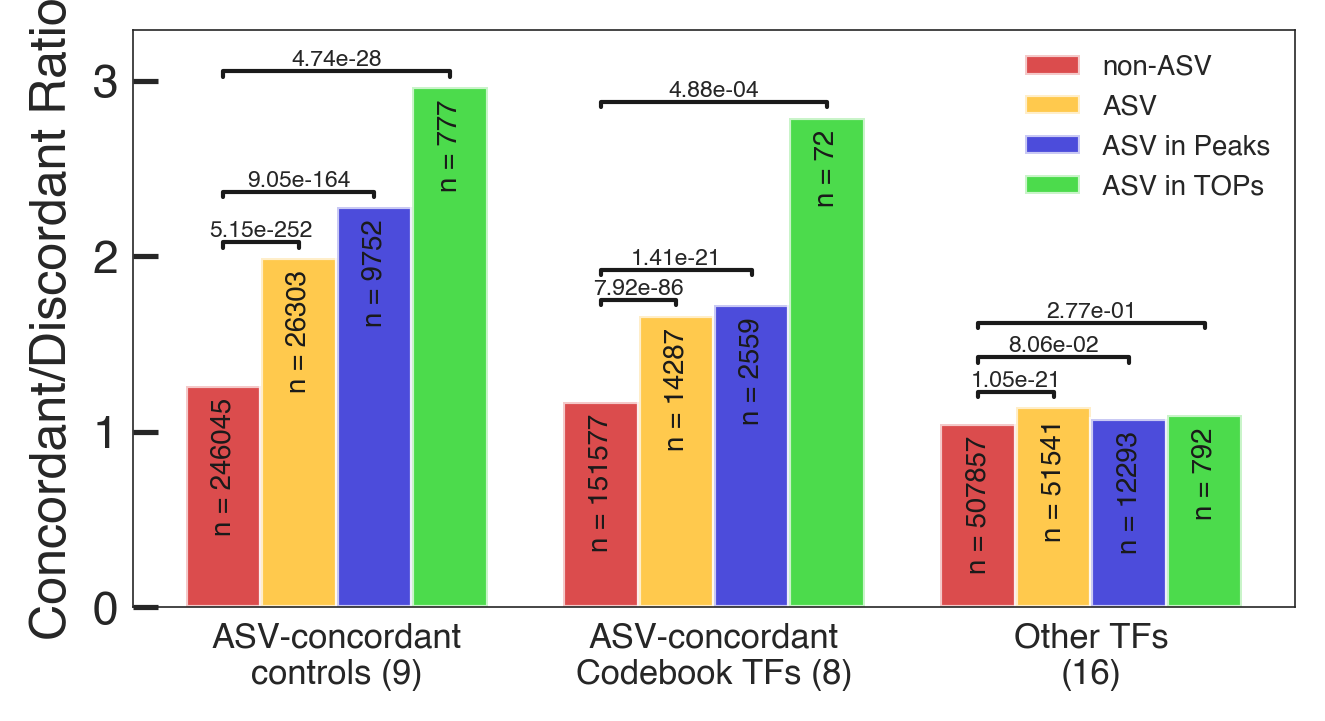

In [52]:
sns.set(font_scale=1, style="ticks", font='Helvetica')

fig, ax = plt.subplots(figsize=(5, 2.5), dpi=300, sharex=True, sharey=True)
for a in ['top', 'bottom', 'right', 'left']:
    ax.spines[a].set_linewidth(0.4)
TEXTSIZE=11
palette = ['#CC0001', '#FFB302', '#00C', '#0C0']

plt.ylim([0, 3.29])
barplot = sns.barplot(data=barplots_big, x='Group', y='ratio', hue='Regions', 
                      ax=ax, palette=palette, saturation=1, alpha=0.7)


br_heights = {reg: i for i, reg in enumerate('ASV;ASV in Peaks;ASV in TOPs'.split(';'))}
nonASV_dct = {}
for i, (p, (_, row)) in enumerate(zip(barplot.patches, barplots_big.iterrows())):
    reg = row['Regions']
    gr = row['Group']
    x = p.get_x() + p.get_width() / 2.
    y = p.get_height() - 0.07
    n = row['conc'] + row['disc']
    text = f'n = {n}'
    plt.text(
        x, y, text, fontsize=TEXTSIZE*0.6, 
        color='k',
        va='top', ha='center', rotation=90,
            )
    if reg == 'non-ASV':
        nonASV_dct[gr] = p
        continue
    nonASV_p = nonASV_dct[gr]
    x1 = nonASV_p.get_x() + nonASV_p.get_width() / 2.
    x2 = p.get_x() + p.get_width() / 2.
    factor = 0.3
    start_point = 1.2
    y1_inferred = start_point + factor*(br_heights[reg])*0.65
    y1_act = p.get_height() + factor*0.2
    if gr == groups[-1] or i == 7:
        
        y1 = y1_inferred
        if i == 7:
            y1 += 0.5
    else:
        y1 = y1_act
    y2 = y1 + 0.03
    pv = row['PVal']
    if pv >= 0.05:
        text = 'n.s.'
        fs = TEXTSIZE * 0.6
        sp = factor*0.2
    elif pv > 0.0005:
        text = '*'
        fs = TEXTSIZE * 1
        sp = 0
    else:
        text = '**'
        fs = TEXTSIZE * 1
        sp = 0
    text = f'{pv:.2e}'
    fs = TEXTSIZE / 2
    sp = factor*0.2
    ax.plot([x1,x1, x2, x2], [y1, y2, y2, y1], linewidth=1, color='k')
    ax.text((x1 + x2)/2, y2 + sp, text, ha='center', va='center', fontsize=fs)

plt.legend(loc='upper right', ncol=1, fontsize=TEXTSIZE*0.6, frameon=False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in", length=0)

plt.xticks(fontsize=TEXTSIZE*0.75)
    
plt.ylabel('Concordant/Discordant Ratio')
plt.xlabel('')
plt.savefig(WORK_DIR / 'figures' / 'concordance_barplots.png', bbox_inches='tight')
plt.savefig(WORK_DIR / 'figures' / 'concordance_barplots.pdf', bbox_inches='tight')
plt.show()